In [7]:
from PIL import Image, ImageFile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [10]:
# Allow PIL to open damaged/truncated JPG files
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Load image
img = Image.open("00.jpg").convert("RGB")
img = np.array(img)

# If img has alpha channel, remove it
if img.shape[-1] == 4:
    img = img[..., :3]

H, W, C = img.shape
assert C == 3, f"Expected RGB image with 3 channels, got {C}"

# Flatten image pixels
X = img.reshape(-1, 3).astype(np.float32)

Explained variance ratio: [0.97106093 0.02748656 0.0014525 ]


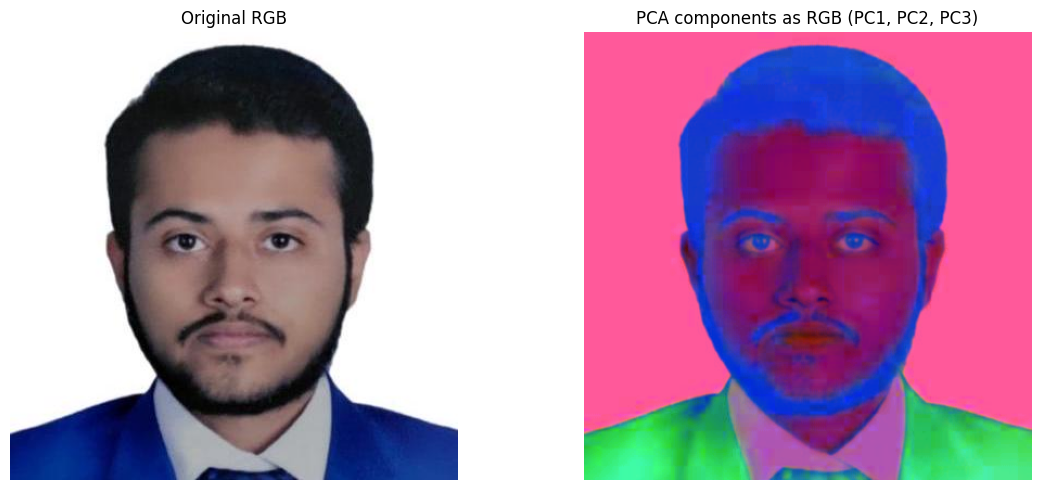

In [11]:

# If image is uint8 [0..255], scaling isn't strictly required for PCA,
# but converting to float is. You can optionally normalize:
# X /= 255.0

# ---- PCA ----
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)          # shape: (H*W, 3)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# ---- Make a 3-channel visualization image from the 3 PCs ----
# Each component can be negative; scale each PC to [0,1] for display.
scaler = MinMaxScaler(feature_range=(0, 1))
X_pca_scaled = scaler.fit_transform(X_pca)  # still (H*W, 3) but in [0,1]

pca_rgb = X_pca_scaled.reshape(H, W, 3)

# ---- Plot original + PCA visualization ----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pca_rgb)
plt.title("PCA components as RGB (PC1, PC2, PC3)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# --- Load your image (edit path) ---
img = Image.open("00.jpg").convert("RGB")  # or .jpg
X = np.asarray(img).astype(np.float32)             # shape: (H, W, 3)
H, W, C = X.shape
assert C == 3

# --- Reshape to (num_pixels, 3) for PCA over RGB vectors ---
X2 = X.reshape(-1, 3)

In [14]:
# --- PCA ---
pca = PCA(n_components=3, svd_solver="full", random_state=0)
scores = pca.fit_transform(X2)   # shape: (H*W, 3)

# Reshape component score maps back to images (H, W)
pc1 = scores[:, 0].reshape(H, W)
pc2 = scores[:, 1].reshape(H, W)
pc3 = scores[:, 2].reshape(H, W)

def norm01(a):
    a = a.astype(np.float32)
    a = a - a.min()
    denom = a.max() - a.min()
    return a / denom if denom > 0 else a

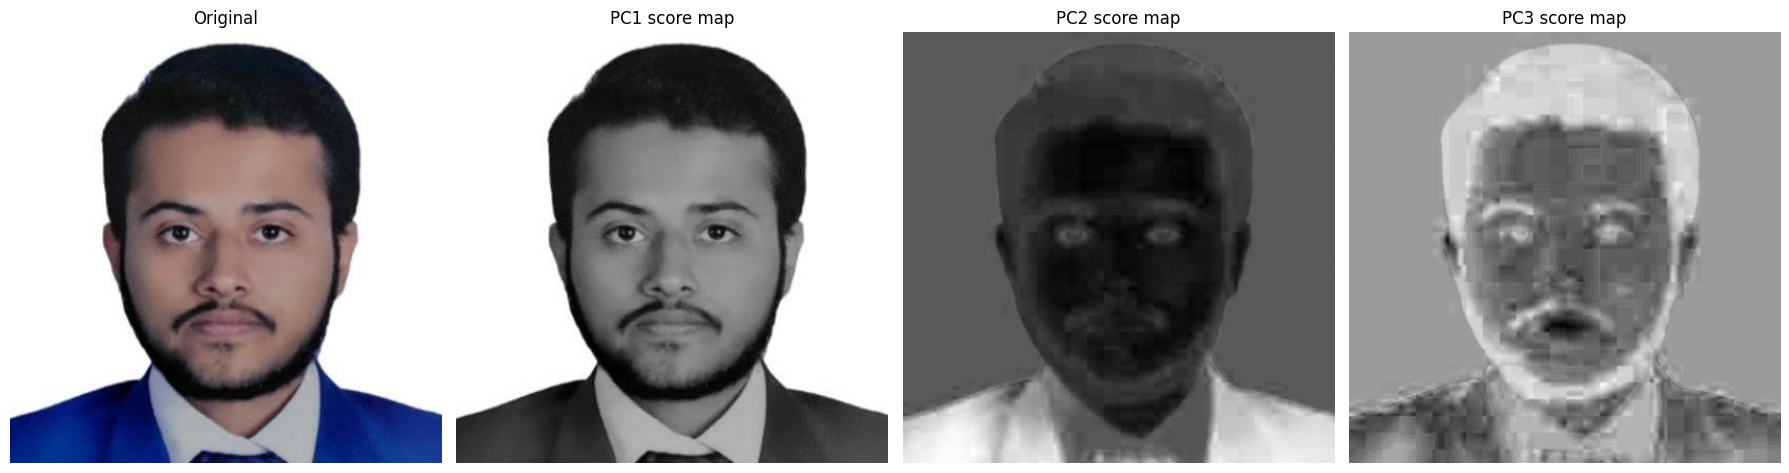

In [15]:
# --- Visualize ---
fig, axs = plt.subplots(1, 4, figsize=(18, 5))

axs[0].imshow(X.astype(np.uint8))
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(norm01(pc1), cmap="gray")
axs[1].set_title("PC1 score map")
axs[1].axis("off")

axs[2].imshow(norm01(pc2), cmap="gray")
axs[2].set_title("PC2 score map")
axs[2].axis("off")

axs[3].imshow(norm01(pc3), cmap="gray")
axs[3].set_title("PC3 score map")
axs[3].axis("off")

plt.tight_layout()
plt.show()
